In [271]:
import numpy as np
import matplotlib.pyplot as plt
%load_ext autoreload
%autoreload 2

import sys
import os
sys.path.append(os.path.abspath('..'))
from lib_algebra import QR_dec


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [272]:

plt.rcParams.update({
    "text.usetex": True,           # Attiva l'uso di LaTeX per tutto il testo
    "font.family": "serif",        # Usa un font Serif per il testo normale
    "font.serif": ["Palatino"],    # Specifica Palatino (molto simile a quello in foto)
    "axes.labelsize": 16,          # Dimensione font etichette assi
    "font.size": 14,                # Dimensione font generale
    "legend.fontsize": 14,         # Dimensione font legenda
    "xtick.labelsize": 13,         # Dimensione numeri asse x
    "ytick.labelsize": 13,         # Dimensione numeri asse y
    "figure.figsize": (8, 6),      # Dimensione predefinita della figura
    "figure.dpi": 300,             # Risoluzione
    
    "text.latex.preamble": r"\usepackage{amsmath} \usepackage{amssymb}"
})



## **Heat Equation**
Write a class that given the discrete set of coordinates $x_j$ calculates and stores the matrix $M_{jk}$. Add the methods dft and idft, both accepting an array of the same length as $x_j$ and returning either the direct or inverse DFT (internally the two methods apply either the matrix or its dagger).Starting from following parameters
- $L = 2\pi$ 
- $N = 128$
- $\alpha = 0.5$
- $u(x, 0) = \sin(x) + 0.5 \sin(3x)$
 
solve the 1d Heat equation by implementing these steps:apply the direct DFT to $u(x, 0)$ and calculate $\tilde{u}(k, 0)$ calculate $\tilde{u}(k, t)$ apply the inverse DFT to $\tilde{u}(k, t)$ to find $u(x, t)$

Repeat this operation for 20 values of $t \in [0, 2]$ and then plot them together.

In [273]:
class DFT:
    def __init__(self, x_desc):
        N = len(x_desc)
        L = (x_desc[-1] - x_desc[0])
        
        if N % 2 == 0: 
            p_pos = np.arange(N/2+1)  # positive values bcs of Niquist (even)
            p_neg = np.arange(1, N - (N/2)) * (-1)
        else: 
            p_pos = np.arange(N/2)  # positive values bcs of Niquist (odd)
            p_neg = np.arange(1, N - (N/2)) * (-1)

        p = 2 * np.pi / L * np.concatenate((p_pos, p_neg))
        W = np.exp(1j * np.outer(p, x_desc))

        self.W = W
        self.p = p
        self.N = N
        self.L = L
        self.dx = L / N
    
    def dft(self, y_desc):
        if type(y_desc)==int or len(y_desc) != self.N:
            raise ValueError('len(y_desc) must be equal to len(x_desc)!!')
        y_dft = self.dx * self.W @ y_desc
        return y_dft

    def idft(self, y_desc):
        if type(y_desc)==int or len(y_desc) != self.N:
            raise ValueError('len(y_desc) must be equal to len(x_desc)!!')
        y_idft = self.L**(-1) * self.W.conj().T @ y_desc
        return y_idft
    

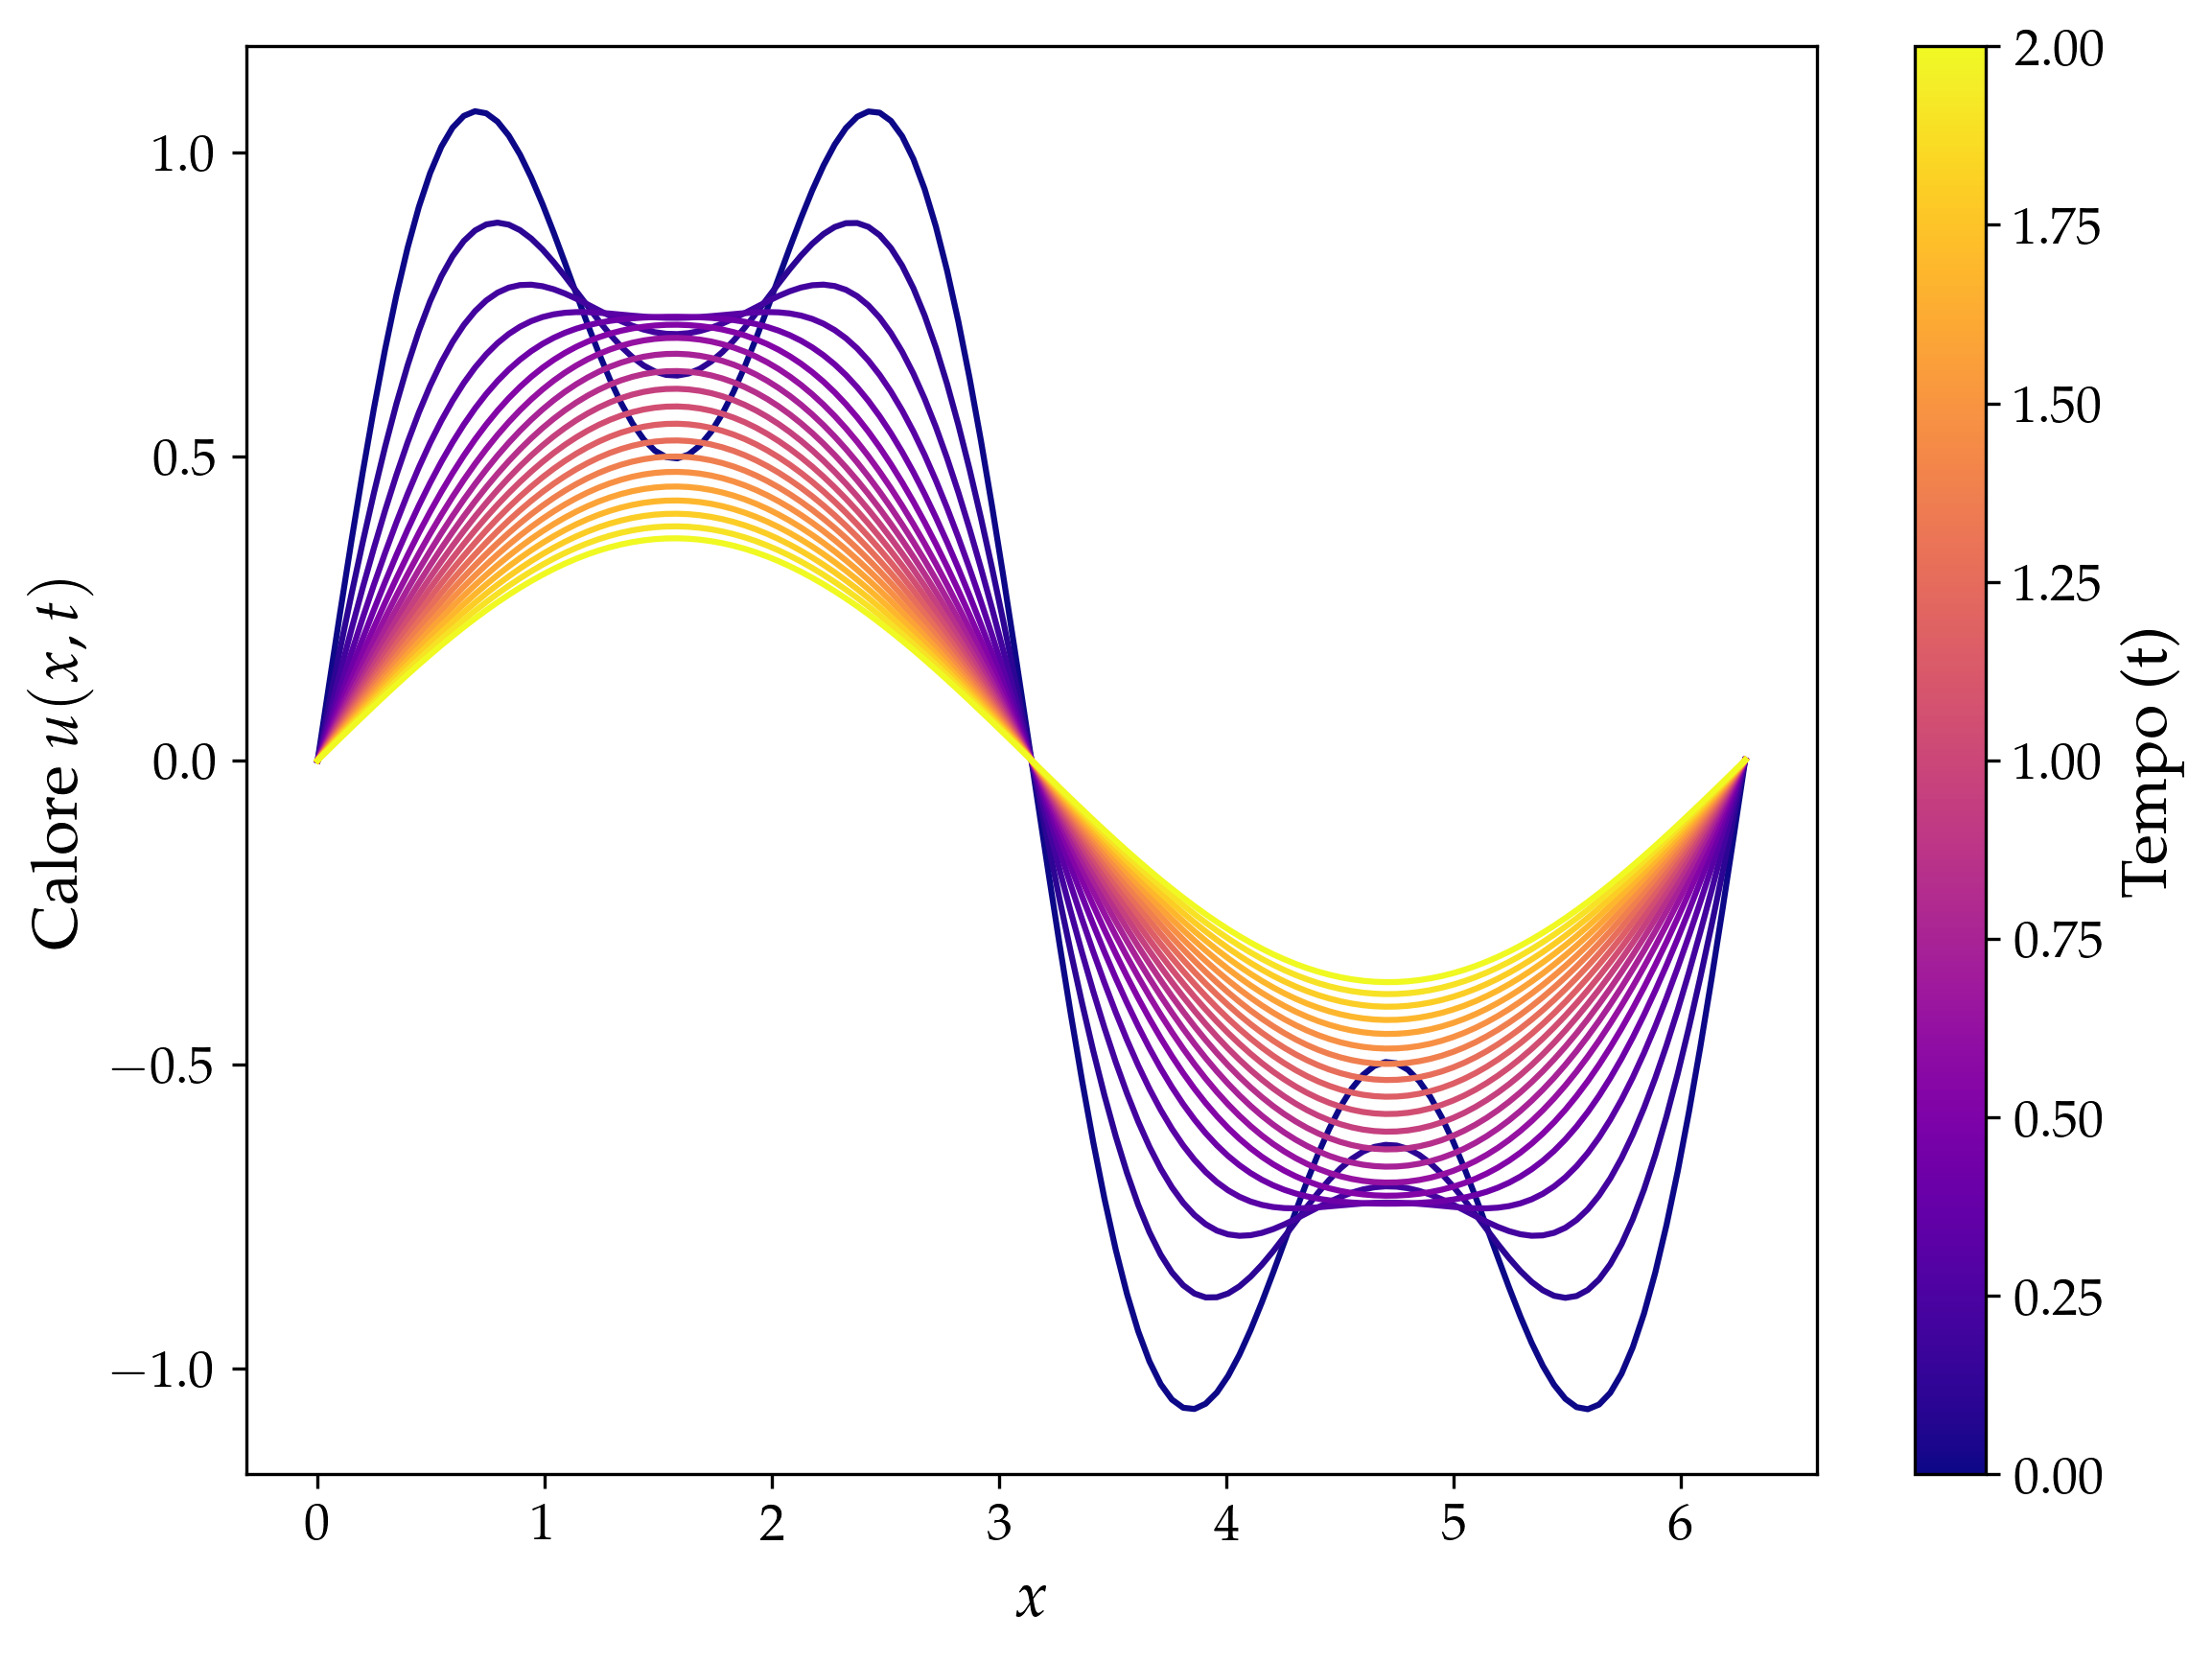

In [274]:
Lmax = 2*np.pi
N_p = 128
alpha = 0.5
xcoo = np.linspace(0, Lmax, N_p, endpoint=True, dtype=float)
times = np.linspace(0, 2, 20, dtype=float)
u0 = np.sin(xcoo) + 0.5 * np.sin(3*xcoo)
heat_dft = DFT(xcoo)
ps = heat_dft.p

# --------------------------
#           PLOT
# --------------------------

cmap = plt.cm.plasma
colors = cmap(np.linspace(0, 1, len(times)))

plt.figure()

# fourier transform of u(x,0) (p-space)
udf_0 = heat_dft.dft(u0)
for i, ti in enumerate(times):
    # u(p,t), analitical solution in the p-space
    u_pt = udf_0 * np.exp(-alpha * ps**2 * ti)
    
    # inverse fourier transform: u(p,t) ---> u(x,t) (x-space)
    u_t = heat_dft.idft(u_pt)

    plt.plot(xcoo, u_t, color=colors[i])

sm = plt.cm.ScalarMappable(cmap=cmap)
sm.set_array(times)
cbar = plt.colorbar(sm, ax=plt.gca())
cbar.set_label(r'Tempo (t)')
plt.xlabel(r'$x$')
plt.ylabel(r'Calore $u(x,t)$')

plt.tight_layout()
plt.savefig('plots/heat_sol.png', dpi=300)
plt.show()